<center> <h1> Netflix Data Science Project </h1> </center>

In [110]:
#Import required libraries:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from scipy.stats import ttest_ind, chi2_contingency

In [111]:
#Load the data and preprocess it:
df = pd.read_csv("dataset/NetFlix.csv/NetFlix.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop_duplicates().copy()

# Replace fake missing values
df.replace(["nan", "None", ""], np.nan, inplace=True)

# Fill text columns
text_cols = ["director", "cast", "country", "rating", "genres", "description"]
for col in text_cols:
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()

# Dates
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce", dayfirst=True)
df["date_added"] = df["date_added"].fillna(df["date_added"].dropna().median())

# Numeric cleanup
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["release_year"] = df["release_year"].fillna(df["release_year"].median())

df["duration"] = (
    df["duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["duration"] = df["duration"].fillna(df["duration"].median())

In [112]:
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

df["cast_count"] = df["cast"].apply(lambda x: 0 if x == "Unknown" else len([i for i in x.split(",") if i.strip()]))
df["country_count"] = df["country"].apply(
    lambda x: round(
        0 if x == "Unknown" else len([i for i in str(x).split(",") if i.strip()])
    )
)
df["country_count"] = df["country_count"].astype(int)
df["genre_count"] = df["genres"].apply(lambda x: 0 if x == "Unknown" else len([i for i in x.split(",") if i.strip()]))
df["description_length"] = df["description"].apply(lambda x: len(str(x).strip()))

(7787, 18)
show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
duration              0
genres                0
description           0
added_year            0
added_month           0
cast_count            0
country_count         0
genre_count           0
description_length    0
dtype: int64

Content Type Distribution:
type
Movie      5377
TV Show    2410
Name: count, dtype: int64

Rating Distribution:
rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64


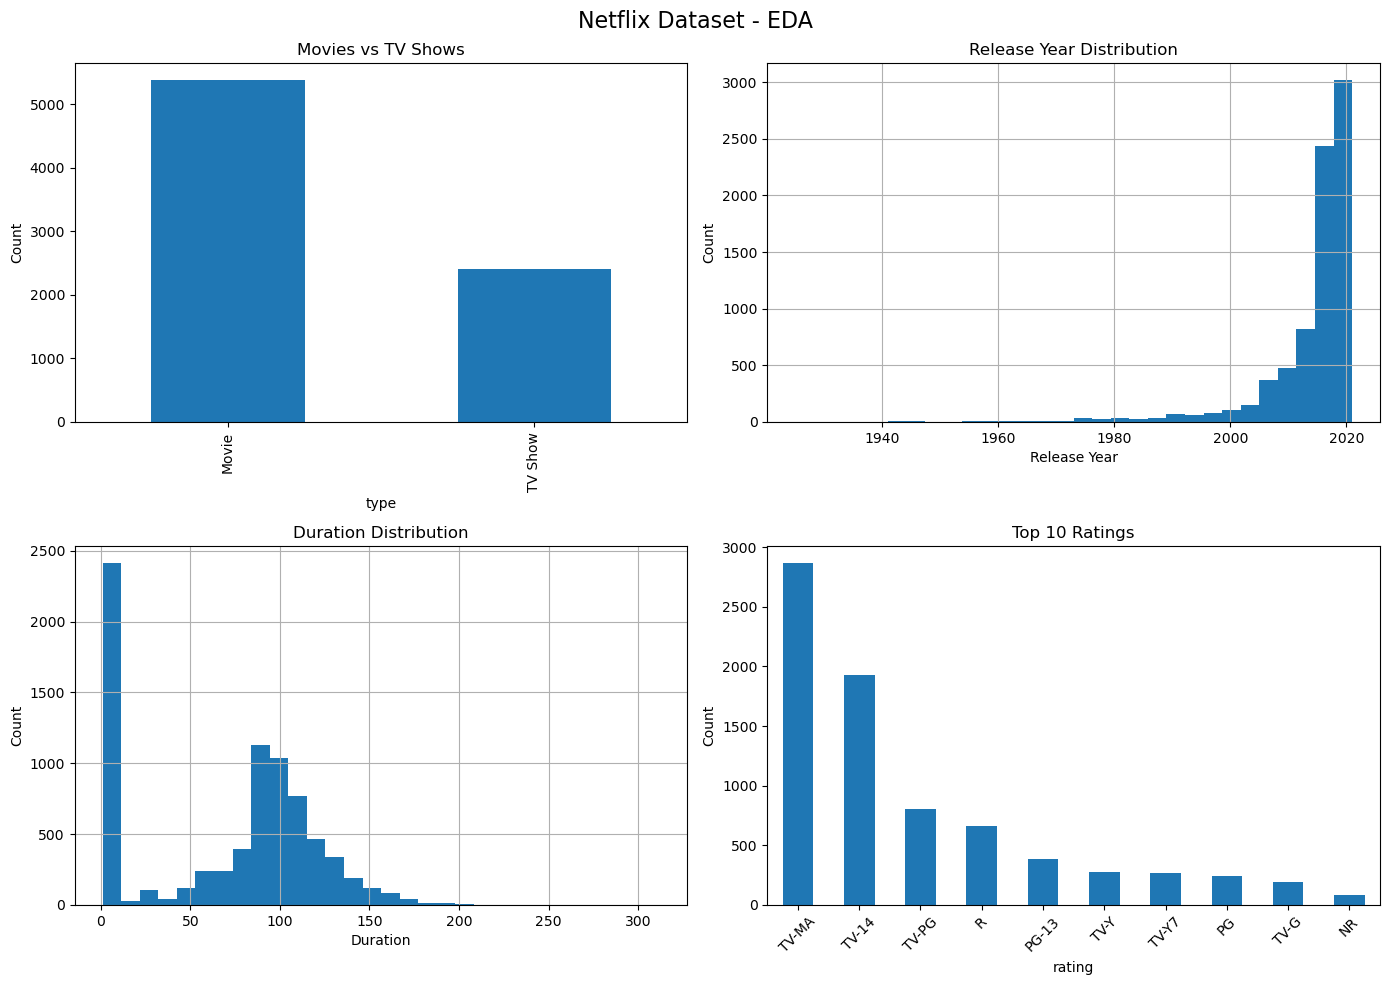

In [113]:
import matplotlib.pyplot as plt

# === Basic EDA ===
print(df.shape)
print(df.isnull().sum())

print("\nContent Type Distribution:")
print(df["type"].value_counts())

print("\nRating Distribution:")
print(df["rating"].value_counts().head(10))

# === Create 2x2 Grid using plt.subplot() ===
plt.figure(figsize=(14, 10))   # Set figure size

plt.subplot(2, 2, 1)
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.ylabel("Count")

plt.subplot(2, 2, 2)
df["release_year"].hist(bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.subplot(2, 2, 3)
df["duration"].hist(bins=30)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")

plt.subplot(2, 2, 4)
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Ratings")
plt.ylabel("Count")
plt.xticks(rotation=45)        # Rotate x labels for better readability

plt.suptitle("Netflix Dataset - EDA", fontsize=16)
plt.tight_layout()             # Important: Prevents overlapping
plt.show()

### Q1] Help Netflix decide whether a content is rich or a simple content?

Accuracy: 0.9088575096277278
              precision    recall  f1-score   support

Content-Rich       0.83      1.00      0.91       709
      Simple       1.00      0.84      0.91       849

    accuracy                           0.91      1558
   macro avg       0.92      0.92      0.91      1558
weighted avg       0.92      0.91      0.91      1558



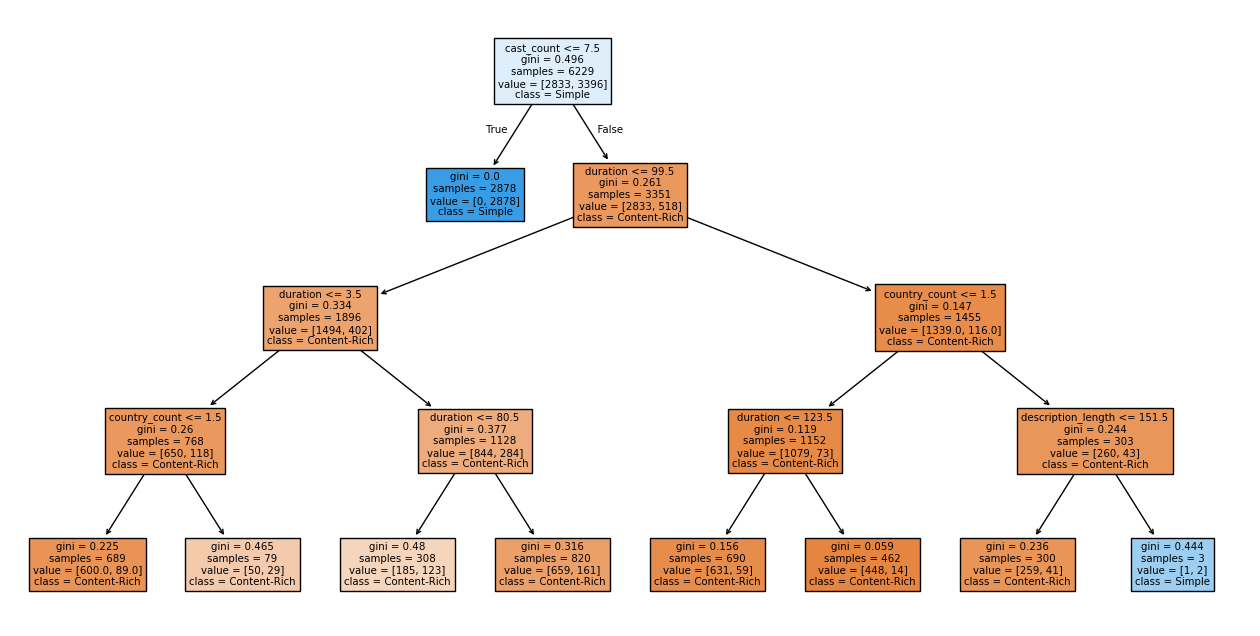

In [114]:
df["content_type"] = np.where(
    (df["genre_count"] >= df["genre_count"].median()) &
    (df["cast_count"] >= df["cast_count"].median()),
    "Content-Rich",
    "Simple"
)

X = df[["duration", "cast_count", "country_count", "description_length"]]
y = df["content_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(16, 8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.show()

### Q2] Netflix wants to check whether the average duration of Movies is different from the average duration of TV Shows in its catalog. Use an appropriate statistical test to determine if the difference is significant.

In [115]:

avg_movie_duration = df[df["type"]=="Movie"]["duration"]
avg_tv_show_duration = df[df["type"]=="TV Show"]["duration"]


from scipy import stats


t_stat, p_val = stats.ttest_ind(avg_movie_duration, avg_tv_show_duration,equal_var=False)

alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis: Significant difference found.")
else:
    print("Fail to reject null hypothesis: No significant difference.")

Reject null hypothesis: Significant difference found.


In [116]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description',
       'added_year', 'added_month', 'cast_count', 'country_count',
       'genre_count', 'description_length', 'content_type'],
      dtype='object')

### Q3] Netflix claims that the average duration of newly released content (after 2020) is 100 minutes. Using the available data, test whether the average duration is actually less than 100 minutes at a 5% significance level.

In [117]:
from statsmodels.stats.weightstats import ztest

new_content = df[
    (df["release_year"] > 2020)
]["duration"].dropna()

population_mean = 100
alpha = 0.05

z_stat, p_value = ztest(new_content, value=population_mean)

# Left-tailed test (less than 100)
p_value = p_value / 2 if z_stat < 0 else 1 - p_value / 2

print(f"Z-Score = {z_stat:.4f}, P-Value = {p_value:.4f}")

if p_value < alpha:
    print("Reject H0: Average duration is significantly less than 100 minutes.")
else:
    print("Fail to reject H0: No evidence that average duration is less than 100.")

Z-Score = -8.7620, P-Value = 0.0000
Reject H0: Average duration is significantly less than 100 minutes.


### Q4] A streaming platform wants to segment its content into different groups based on features like duration, number of genres, cast size, country count, and description length. Before clustering, reduce the feature dimensions to 2 using PCA for better visualization.

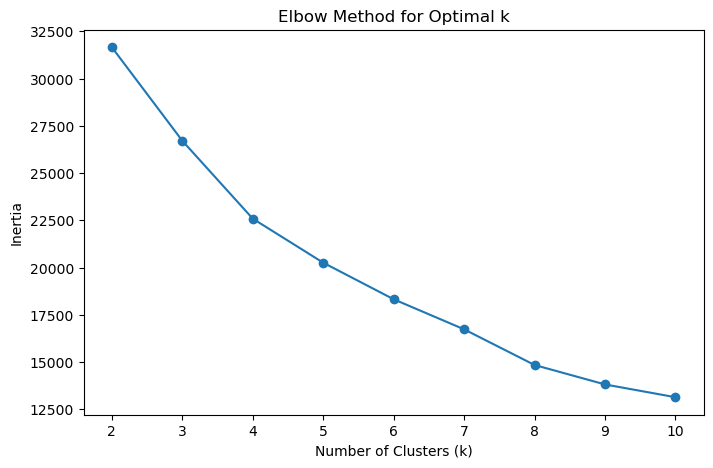

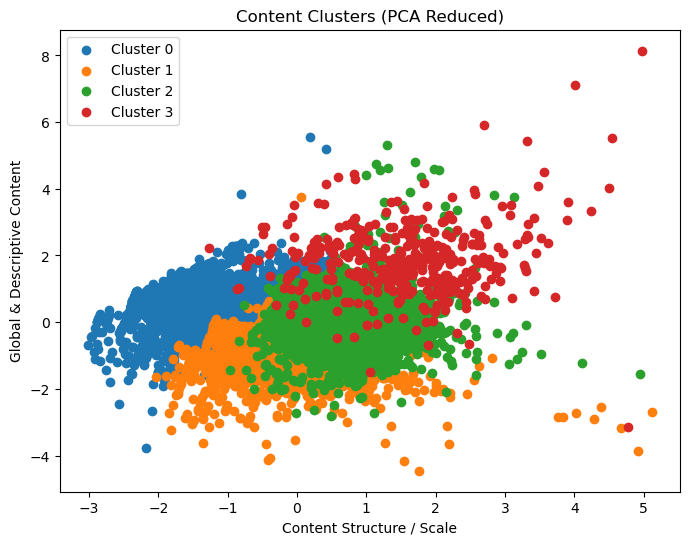

In [118]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Select features
feature_cols = [
    "duration",
    "genre_count",
    "cast_count",
    "country_count",
    "description_length"
]

X = df[feature_cols].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Elbow Method
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Final KMeans model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Plot clusters using PCA-reduced data
plt.figure(figsize=(8, 6))

for i in range(4):
    plt.scatter(
        X_pca[clusters == i, 0],
        X_pca[clusters == i, 1],
        label=f"Cluster {i}"
    )

plt.xlabel("Content Structure / Scale")
plt.ylabel("Global & Descriptive Content")
plt.title("Content Clusters (PCA Reduced)")
plt.legend()
plt.show()

In [119]:
pca_df = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=["PC1", "PC2"]
)

print(pca_df)

     duration  genre_count  cast_count  country_count  description_length
PC1  0.489091     0.514842    0.581285       0.386156            0.093377
PC2  0.383576    -0.512526   -0.291288       0.518344            0.486475


## Final Conclusion

This project analyzed Netflix content using data cleaning, exploratory data analysis, statistical testing, and unsupervised machine learning. The dataset was first cleaned and transformed to create useful analytical features such as `genre_count`, `cast_count`, `country_count`, and `description_length`, which made the content more suitable for both business interpretation and modeling.

From the exploratory analysis, the Netflix catalog showed meaningful variation in content structure, duration, and descriptive richness. Some titles appeared more compact and simple, while others were longer, had broader genre coverage, larger casts, and stronger global presence. This indicates that Netflix content cannot be treated as one uniform catalog and instead contains multiple content patterns that can be studied separately.

The hypothesis testing section helped validate whether differences observed in the data were statistically meaningful rather than random. This made the project stronger than a basic EDA notebook because it moved beyond visual observation and added formal statistical reasoning to the analysis.

To better understand hidden structure in the dataset, PCA was used to reduce the feature space into two principal components for visualization. These components captured patterns related to content structure, scale, global reach, and descriptive detail. After dimensionality reduction, K-Means clustering was applied to segment the catalog into interpretable groups. The clustering results showed that Netflix titles can be grouped into distinct segments based on their structural and descriptive characteristics, which can help support content strategy, catalog organization, and recommendation design.

Overall, this project demonstrates how a real-world entertainment dataset can be turned into business insight through a complete data science workflow. It combines cleaning, feature engineering, statistics, dimensionality reduction, and clustering in a way that is simple, interpretable, and practically useful.

## Project by:
- **Name** : Om Satyawan Pathak
- **Email** : omsatyawanpathakgit@gmail.com _**(or)**_ omsatyawanpathakwebdevelopment@gmail.com
- **Contact** : +91 - 9426048518
- **Date created** : 15 April 2026